# Pitch Predictions - XGBoost


## Imports and Loading Data

In [29]:
import numpy as np
import pandas as pd
import pickle
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
 
print("Imports successful")
 
# Load data
print("\nLoading feature data...")
X_train = np.load('../../feature-engineering/X_train.npy')
X_test = np.load('../../feature-engineering/X_test.npy')
y_train = np.load('../../feature-engineering/y_train.npy')
y_test = np.load('../../feature-engineering/y_test.npy')
 
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
 
# Load feature names and encoder
with open('../../feature-engineering/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)
 
with open('../../feature-engineering/pitch_type_encoder.pkl', 'rb') as f:
    pitch_encoder = pickle.load(f)
 
print(f"\nLoaded {len(feature_names)} features and {len(pitch_encoder.classes_)} pitch types")

Imports successful

Loading feature data...
X_train shape: (482656, 26)
X_test shape: (117758, 26)
y_train shape: (482656,)
y_test shape: (117758,)

Loaded 26 features and 17 pitch types


## Baseline accuracy

In [30]:
# Most common pitch in training set
unique, counts = np.unique(y_train, return_counts=True)
most_common_pitch_idx = unique[np.argmax(counts)]
most_common_pitch = pitch_encoder.classes_[most_common_pitch_idx]
baseline_accuracy = np.max(counts) / len(y_train)
 
print(f"\nMost common pitch: {most_common_pitch}")
print(f"Baseline accuracy (train): {baseline_accuracy:.1%}")
 
# Baseline on test set (always predict most common)
baseline_test_accuracy = (y_test == most_common_pitch_idx).sum() / len(y_test)
print(f"Baseline accuracy (test): {baseline_test_accuracy:.1%}")
 
print(f"\nTARGET: Beat {baseline_test_accuracy:.1%} accuracy")


Most common pitch: FF
Baseline accuracy (train): 30.5%
Baseline accuracy (test): 31.0%

TARGET: Beat 31.0% accuracy


## Training

In [31]:
# Tuned for multi-class pitch prediction
model = XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,  # Use all cores
    verbose=1,
    tree_method='hist',  # Fast histogram-based method
)
 
print("\nTraining (this may take 30-60 seconds)...")
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
 
print("Training complete!")


Training (this may take 30-60 seconds)...
Training complete!


## Evaluation on Test Set

In [32]:
# Predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
 
# Accuracy
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
 
print(f"\nAccuracy:")
print(f"  Train: {train_accuracy:.3f} ({train_accuracy:.1%})")
print(f"  Test:  {test_accuracy:.3f} ({test_accuracy:.1%})")
print(f"  Baseline: {baseline_test_accuracy:.1%}")
print(f"  Improvement over baseline: +{(test_accuracy - baseline_test_accuracy):.1%}")
 
# Per-pitch accuracy
print(f"\nPer-pitch type accuracy (test set):")
pitch_types = pitch_encoder.classes_
for i, pitch in enumerate(pitch_types):
    mask = y_test == i
    if mask.sum() > 0:
        acc = accuracy_score(y_test[mask], y_pred_test[mask])
        count = mask.sum()
        print(f"  {pitch:3s}: {acc:.1%} ({count:6d} pitches)")


Accuracy:
  Train: 0.472 (47.2%)
  Test:  0.435 (43.5%)
  Baseline: 31.0%
  Improvement over baseline: +12.6%

Per-pitch type accuracy (test set):
  CH : 31.8% ( 13948 pitches)
  CS : 0.0% (     6 pitches)
  CU : 8.0% (  5394 pitches)
  EP : 89.5% (   133 pitches)
  FA : 7.1% (    14 pitches)
  FC : 24.6% (  8671 pitches)
  FF : 67.1% ( 36463 pitches)
  FS : 22.4% (  2866 pitches)
  KC : 0.1% (  3511 pitches)
  PO : 0.0% (     4 pitches)
  SI : 54.4% ( 20704 pitches)
  SL : 28.6% ( 16164 pitches)
  ST : 32.4% (  9693 pitches)
  SV : 0.0% (   185 pitches)
  UN : 0.0% (     2 pitches)


## Confusion Matrix


Most common confusions (predicted != actual):
  Actual PO -> Predicted FF:  7240 times (181000.0%)
  Actual CH -> Predicted FF:  7099 times ( 50.9%)
  Actual KN -> Predicted FF:  4062 times (  0.0%)
  Actual SI -> Predicted FF:  3376 times ( 16.3%)
  Actual FC -> Predicted FF:  3226 times ( 37.2%)
  Actual FF -> Predicted CH:  3138 times (  8.6%)
  Actual PO -> Predicted KN:  3034 times (75850.0%)
  Actual FF -> Predicted KN:  2919 times (  8.0%)
  Actual FF -> Predicted PO:  2727 times (  7.5%)
  Actual CU -> Predicted FF:  2633 times ( 48.8%)
  Actual FS -> Predicted FF:  1974 times ( 68.9%)
  Actual SI -> Predicted KN:  1906 times (  9.2%)
  Actual FC -> Predicted KN:  1811 times ( 20.9%)
  Actual FO -> Predicted FF:  1597 times (  0.0%)
  Actual FF -> Predicted SI:  1585 times (  4.3%)

Generating confusion matrix heatmap...
Saved xgboost_confusion_matrix.png


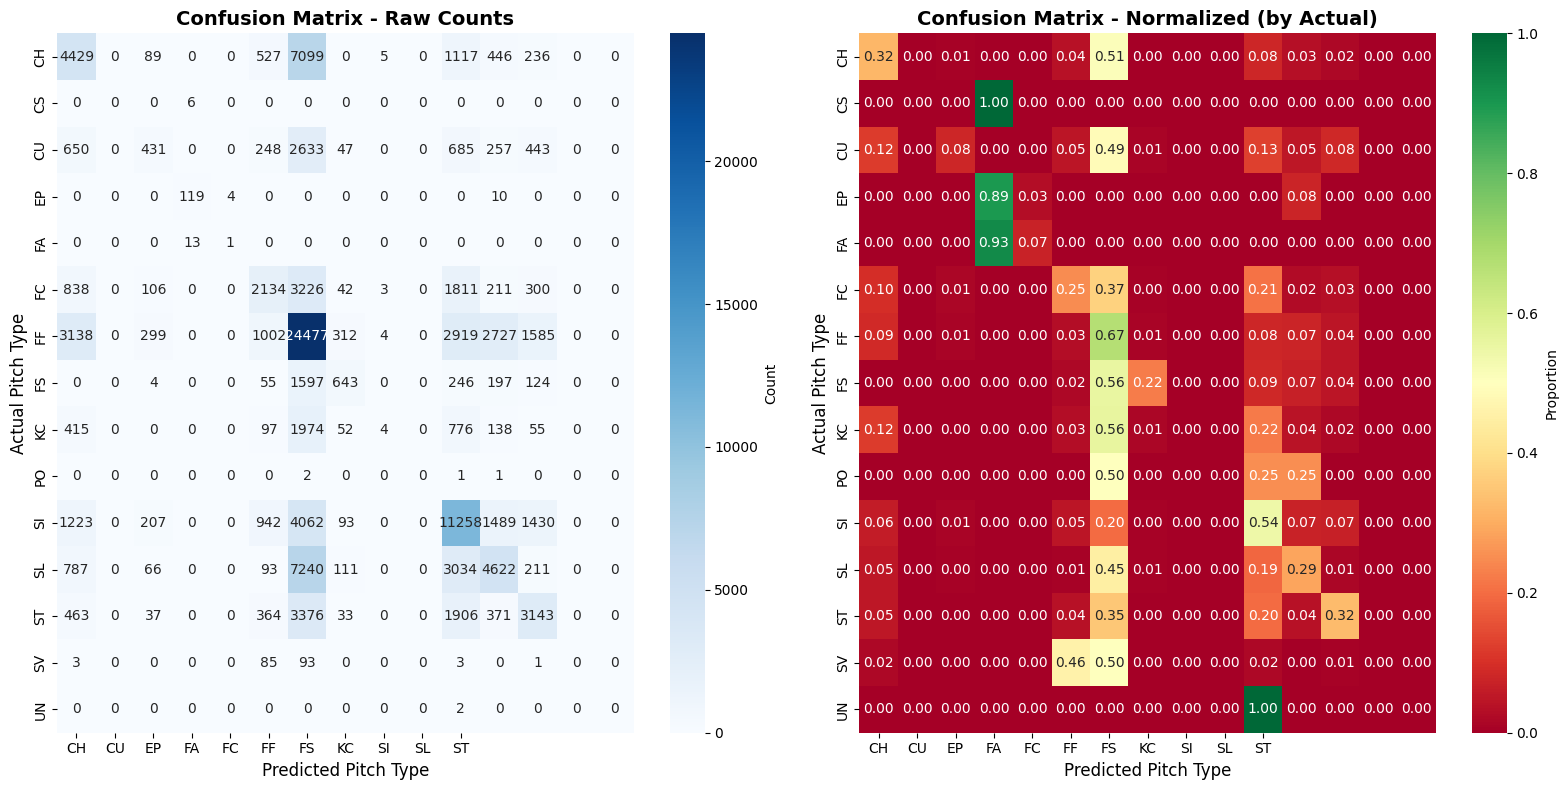

In [36]:
# TODO: Print a matrix visualization
cm = confusion_matrix(y_test, y_pred_test)
 
print("\nMost common confusions (predicted != actual):")
confusions = []
 
# Handle case where test set doesn't have all pitch types
# cm shape is (n_actual_classes, n_predicted_classes)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i != j:
            count = cm[i, j]
            if count > 0:
                # Get pitch names - handle missing classes
                actual_pitch = pitch_types[i] if i < len(pitch_types) else f"Unknown_{i}"
                pred_pitch = pitch_types[j] if j < len(pitch_types) else f"Unknown_{j}"
                confusions.append((actual_pitch, pred_pitch, count))
 
# Sort by frequency
confusions.sort(key=lambda x: x[2], reverse=True)
for actual, predicted, count in confusions[:15]:
    # Calculate percentage safely
    actual_idx = np.where(pitch_types == actual)[0]
    if len(actual_idx) > 0:
        total_actual = (y_test == actual_idx[0]).sum()
        pct = count / total_actual * 100 if total_actual > 0 else 0
        print(f"  Actual {actual} -> Predicted {predicted}: {count:5d} times ({pct:5.1f}%)")


# Confusion Matrix Heatmap
print("\nGenerating confusion matrix heatmap...")
 
# Create a DataFrame for the confusion matrix with pitch type labels
# Normalize by row (actual pitch type) to show percentages
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
 
# Get the actual pitch types that appear in the test set
actual_pitch_indices = np.unique(y_test)
predicted_pitch_indices = np.unique(y_pred_test)
 
# Get pitch type labels
actual_pitches = pitch_types[actual_pitch_indices]
predicted_pitches = pitch_types[predicted_pitch_indices]
 
# Create heatmap (may be rectangular if different pitches appear in actual vs predicted)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
 
# Count-based heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=predicted_pitches, yticklabels=actual_pitches,
            cbar_kws={'label': 'Count'}, ax=ax1)
ax1.set_title('Confusion Matrix - Raw Counts', fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicted Pitch Type', fontsize=12)
ax1.set_ylabel('Actual Pitch Type', fontsize=12)
 
# Normalized heatmap (% of actual pitch type)
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='RdYlGn', 
            xticklabels=predicted_pitches, yticklabels=actual_pitches,
            cbar_kws={'label': 'Proportion'}, ax=ax2, vmin=0, vmax=1)
ax2.set_title('Confusion Matrix - Normalized (by Actual)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Predicted Pitch Type', fontsize=12)
ax2.set_ylabel('Actual Pitch Type', fontsize=12)
 
plt.tight_layout()
plt.savefig('xgboost_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("Saved xgboost_confusion_matrix.png")
plt.show()


## Feature Importance

In [34]:
importance = model.feature_importances_
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance,
    'importance_pct': importance / importance.sum() * 100
}).sort_values('importance', ascending=False)
 
print("\nTop 20 features:")
print(importance_df.head(20).to_string(index=False))


Top 20 features:
           feature  importance  importance_pct
            FA_pct    0.127065       12.706457
            SV_pct    0.097854        9.785443
            FS_pct    0.082242        8.224165
            ST_pct    0.076582        7.658181
            FO_pct    0.075370        7.536988
            KC_pct    0.074688        7.468806
            FC_pct    0.063706        6.370611
            SL_pct    0.057950        5.795043
            SI_pct    0.053994        5.399354
            CU_pct    0.047831        4.783099
            CH_pct    0.046577        4.657730
handedness_matchup    0.039124        3.912390
            FF_pct    0.039061        3.906119
      pitcher_hand    0.025775        2.577465
            KN_pct    0.020129        2.012874
            CS_pct    0.014549        1.454865
           strikes    0.012743        1.274310
            EP_pct    0.008345        0.834481
             balls    0.008308        0.830835
            UN_pct    0.006612        0.66

## Export

In [35]:
# Save model
with open('xgboost_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("Saved xgboost_model.pkl")
 
# Save feature importance
importance_df.to_csv('xgboost_feature_importance.csv', index=False)
print("Saved xgboost_feature_importance.csv")
 
# Save predictions
results_df = pd.DataFrame({
    'actual_pitch_idx': y_test,
    'predicted_pitch_idx': y_pred_test,
    'actual_pitch': [pitch_encoder.classes_[i] for i in y_test],
    'predicted_pitch': [pitch_encoder.classes_[i] for i in y_pred_test],
    'correct': y_test == y_pred_test,
})
results_df.to_csv('xgboost_predictions.csv', index=False)
print("Saved xgboost_predictions.csv")

Saved xgboost_model.pkl
Saved xgboost_feature_importance.csv
Saved xgboost_predictions.csv
